# 🔎 **Entrenamiento de los Modelos**

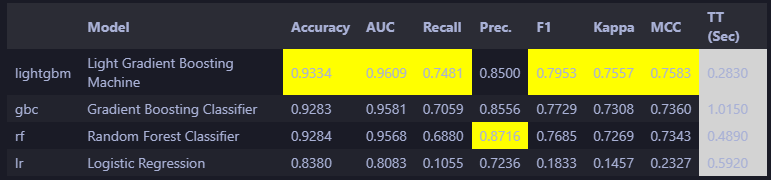

Según el analisís realizado con AutoML, los dos modelos que vamos a entrenar van a ser **Light Gradient Boosting Machine (lightgbm)** y **Gradient Boosting Classifier (gbc)**

---

## **Librerias**

In [72]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import plotly.figure_factory as ff
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib
import plotly.express as px
from sklearn.model_selection import GridSearchCV


In [5]:
DATA_DIR = Path.cwd().parent / "data" / "processed"
datos_cooperativa = pd.read_parquet(DATA_DIR / "02_datos_ajustados_cooperativa.parquet")

## ➜ **Selección de Columnas**

In [4]:
columnas_seleccionadas = [
    'cartera', 
    'plazo', 
    'vinculacion', 
    'valor_cuota', 
    'valor_prestamo',
    'saldo_capital', 
    'saldo_interes', 
    'aportes', 
    'garantias',
    'valorgarantia', 
    'ctasahorros', 
    'edad', 
    'tipoasociado',
    'sexo', 
    'curtotalingresos',
    'curtotalegresos', 
    'intestrato', 
    'actualizacion', 
    'default',
    'puntaje_data', 
    'grupo_ciudad', 
    'grupo_edad',
    'grupo_actividadeco']

In [7]:
df_cooperativa = datos_cooperativa[columnas_seleccionadas]
df_cooperativa.head()

,cartera,plazo,vinculacion,valor_cuota,valor_prestamo,saldo_capital,saldo_interes,aportes,garantias,valorgarantia,...,sexo,curtotalingresos,curtotalegresos,intestrato,actualizacion,default,puntaje_data,grupo_ciudad,grupo_edad,grupo_actividadeco
0,consumo_sin_libranza,1827,8103,356849.0,15000000.0,12923538.0,123855.0,7741255,1,7741255.0,...,0,4597000.0,1500000.0,5,1,False,795.0,1,3,4
1,consumo_sin_libranza,1826,1434,2650409.0,100460000.0,31911361.0,263265.0,4601706,1,4601706.0,...,0,4597000.0,650000.0,5,1,False,836.0,5,3,4
2,consumo_sin_libranza,1826,573,791482.0,30000000.0,23844684.0,261477.0,530431,1,530431.0,...,0,4400000.0,2000000.0,4,0,True,709.0,7,2,4
3,consumo_sin_libranza,2922,1902,2860501.0,176000000.0,113842595.0,1008570.0,3023534,2,320385440.0,...,0,22020000.0,1500000.0,4,1,False,733.0,6,3,1
4,consumo_sin_libranza,2557,1902,987637.0,50300000.0,38521256.0,317167.0,1023082,2,320385440.0,...,0,22020000.0,1500000.0,4,1,False,695.0,6,3,1


In [9]:
columnas_numericas = df_cooperativa.select_dtypes(include=['int64', 'int32']).columns
print("Columnas numéricas:", columnas_numericas)

columnas_categoricas = df_cooperativa.select_dtypes(include=['object', 'category']).columns
print("Columnas categóricas:", columnas_categoricas)

columnas_flotantes = df_cooperativa.select_dtypes(include=['float64', 'float32']).columns
print("Columnas flotantes:", columnas_flotantes)

Columnas numéricas: Index(['plazo', 'vinculacion', 'aportes', 'garantias', 'edad', 'tipoasociado',
       'sexo', 'intestrato', 'actualizacion', 'grupo_ciudad', 'grupo_edad',
       'grupo_actividadeco'],
      dtype='object')
Columnas categóricas: Index(['cartera'], dtype='object')
Columnas flotantes: Index(['valor_cuota', 'valor_prestamo', 'saldo_capital', 'saldo_interes',
       'valorgarantia', 'ctasahorros', 'curtotalingresos', 'curtotalegresos',
       'puntaje_data'],
      dtype='object')


## ➜ **Definición de Variables Numéricas y Categóricas**

In [17]:
#Identificamos las columnas para crear el Pipeline de preprocesamiento


cols_numericas_enteras = ['plazo', 'vinculacion', 'aportes', 'garantias', 'edad', 'tipoasociado',
       'sexo', 'intestrato', 'actualizacion', 'grupo_ciudad', 'grupo_edad',
       'grupo_actividadeco']

cols_categoricas = ['cartera']

cols_flotantes = ['valor_cuota', 'valor_prestamo', 'saldo_capital', 'saldo_interes',
       'valorgarantia', 'ctasahorros', 'curtotalingresos', 'curtotalegresos',
       'puntaje_data']



## ➜ **Creación de pipelines**

In [ ]:
#Variables Categóricas Nominales

categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))      
])

categorical_pipeline


Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

Decidimos usar One-Hot Encoding ya que los modelos no entienden directamente texto y convertiremos cada categoría en una columna, esta técnica permite convertir el texto en una representación númerica sin orden.

In [ ]:
# Variables Númericas

numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())            
])

numerical_pipeline

Pipeline(steps=[('scaler', StandardScaler())])

En nuestro caso decidimos estandarizar las variables númericas ya que tienen escalar diferentes, aunque vamos a entrenar modelos basados en arboles y no necesitan de manera estricta un escalado, lo vamos a usar por:

* Uso y buenas prácticas de pipeline
* Consistencia en el preprocesamiento

Dado que el dataset no presenta valores faltantes, el componente de imputación no se aplica, y el análisis se centra exclusivamente en el impacto del escalado estándar.

## ➜ **Creación ColumnTransformer**

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numericas', numerical_pipeline, cols_numericas_enteras + cols_flotantes),
        ('categoricas_nominales', categorical_pipeline, cols_categoricas),
    ]
)

preprocessor

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['plazo', 'vinculacion', 'aportes',
                                  'garantias', 'edad', 'tipoasociado', 'sexo',
                                  'intestrato', 'actualizacion', 'grupo_ciudad',
                                  'grupo_edad', 'grupo_actividadeco',
                                  'valor_cuota', 'valor_prestamo',
                                  'saldo_capital', 'saldo_interes',
                                  'valorgarantia', 'ctasahorros',
                                  'curtotalingresos', 'curtotalegresos',
                                  'puntaje_data']),
                                ('categoricas_nominales',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cartera'])])

## ➜ **Train y Test**

Dividimos los datos en 80% de Entrenamiento y en 20% para Prueba

In [19]:
X = datos_cooperativa.drop(columns='default')
Y = datos_cooperativa['default']


In [21]:
# 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=100
)

Verificamos sus dimensiones

In [23]:
print("Dimensiones del dataset de entrenamiento", X_train.shape, Y_train.shape)

print("Dimensiones del dataset de validación", X_test.shape, Y_test.shape)

Dimensiones del dataset de entrenamiento (10327, 26) (10327,)
Dimensiones del dataset de validación (2582, 26) (2582,)


In [22]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((10327, 26), (2582, 26), (10327,), (2582,))

## ➜ **Transformaciones**

Aquí transformamos los datos de entrenamiento y los de prueba para evitar data leakage

In [24]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [25]:
X_train_transformed.shape, X_test_transformed.shape

((10327, 24), (2582, 24))

Obtenemos los nombres de las columnas

In [29]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['numericas__plazo', 'numericas__vinculacion', 'numericas__aportes',
       'numericas__garantias', 'numericas__edad',
       'numericas__tipoasociado', 'numericas__sexo',
       'numericas__intestrato', 'numericas__actualizacion',
       'numericas__grupo_ciudad', 'numericas__grupo_edad',
       'numericas__grupo_actividadeco', 'numericas__valor_cuota',
       'numericas__valor_prestamo', 'numericas__saldo_capital',
       'numericas__saldo_interes', 'numericas__valorgarantia',
       'numericas__ctasahorros', 'numericas__curtotalingresos',
       'numericas__curtotalegresos', 'numericas__puntaje_data',
       'categoricas_nominales__cartera_consumo_con_libranza',
       'categoricas_nominales__cartera_consumo_sin_libranza',
       'categoricas_nominales__cartera_vivienda'], dtype=object)

In [30]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns=feature_names)
X_test_transformed = pd.DataFrame(X_test_transformed,columns=feature_names)

In [33]:
X_train_transformed.head()

,numericas__plazo,numericas__vinculacion,numericas__aportes,numericas__garantias,numericas__edad,numericas__tipoasociado,numericas__sexo,numericas__intestrato,numericas__actualizacion,numericas__grupo_ciudad,...,numericas__saldo_capital,numericas__saldo_interes,numericas__valorgarantia,numericas__ctasahorros,numericas__curtotalingresos,numericas__curtotalegresos,numericas__puntaje_data,categoricas_nominales__cartera_consumo_con_libranza,categoricas_nominales__cartera_consumo_sin_libranza,categoricas_nominales__cartera_vivienda
0,-0.503952,0.628132,0.009240,-0.325871,0.005225,-1.110997,1.072434,-0.662210,-1.081030,1.082606,...,-0.174482,0.050347,-0.051717,-0.117693,-0.217765,-0.050271,0.255349,0.0,1.0,0.0
1,0.066579,0.726295,0.920940,-0.325871,-0.157305,0.900093,1.072434,0.417803,-1.081030,1.082606,...,-0.079412,-0.171956,-0.045032,0.240393,0.016755,-0.033887,0.901898,0.0,1.0,0.0
2,0.832496,-0.184489,-0.650294,-0.325871,-1.051219,0.900093,1.072434,-0.662210,0.925043,-0.015417,...,-0.032960,-0.179934,-0.056553,-0.119547,-0.214703,-0.053548,-2.362646,0.0,1.0,0.0
3,0.066579,1.342591,0.731995,-0.325871,0.817875,-1.110997,-0.932458,-0.662210,0.925043,-0.015417,...,0.137551,-0.150146,-0.025615,0.095046,0.148111,-0.021107,0.350741,1.0,0.0,0.0
4,0.637109,-0.123832,-0.074108,-0.325871,0.980404,0.900093,1.072434,0.417803,-1.081030,0.533595,...,-0.201714,-0.149129,-0.052328,0.080182,-0.341530,-0.046994,-1.726696,0.0,1.0,0.0


In [34]:
X_test_transformed.head()

,numericas__plazo,numericas__vinculacion,numericas__aportes,numericas__garantias,numericas__edad,numericas__tipoasociado,numericas__sexo,numericas__intestrato,numericas__actualizacion,numericas__grupo_ciudad,...,numericas__saldo_capital,numericas__saldo_interes,numericas__valorgarantia,numericas__ctasahorros,numericas__curtotalingresos,numericas__curtotalegresos,numericas__puntaje_data,categoricas_nominales__cartera_consumo_con_libranza,categoricas_nominales__cartera_consumo_sin_libranza,categoricas_nominales__cartera_vivienda
0,-0.503952,0.511448,0.313346,3.117302,2.036849,0.900093,1.072434,0.417803,0.925043,-1.662452,...,-0.283736,-0.174448,-0.049487,-0.066441,-0.236445,-0.056824,0.435535,0.0,1.0,0.0
1,-0.503952,1.672732,-0.155158,-0.325871,-0.319835,-1.110997,-0.932458,1.497815,0.925043,-0.015417,...,-0.232021,-0.165855,-0.025246,-0.015915,0.410371,0.011989,0.933696,1.0,0.0,0.0
2,-0.503952,-0.814675,-0.398637,-0.325871,0.574080,0.900093,-0.932458,-1.742222,0.925043,1.082606,...,-0.209593,-0.119577,-0.054707,-0.033614,-0.173938,-0.033887,-3.072790,0.0,1.0,0.0
3,0.046259,-0.883204,-0.553934,-0.325871,-0.563629,0.900093,-0.932458,0.417803,-1.081030,-1.113441,...,-0.106184,-0.179934,-0.055846,-0.115174,-0.196585,-0.063378,0.764109,0.0,1.0,0.0
4,-1.074482,1.088386,0.676422,3.117302,2.036849,0.900093,1.072434,-0.662210,-1.081030,-0.015417,...,-0.251952,-0.165733,-0.046825,-0.020859,-0.236445,-0.053548,0.403737,0.0,1.0,0.0


## ➜ **Modelos**

En nuestro caso vamos a entrenar estos dos modelos:

* **LightGBM**
* **Gradient Boosting Classifier (GBC)**

In [38]:
#Metricas 

def metricas_clasificación(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    return {"exactitud": acc,
            "precision": prec,
            "recall": recall,
            "f1": f1,
            "roc": roc}

In [41]:
models = {
    "LightGBM": LGBMClassifier(random_state=42),
    "GBC": GradientBoostingClassifier(random_state=42)
}

In [44]:
models

{'LightGBM': LGBMClassifier(random_state=42),
 'GBC': GradientBoostingClassifier(random_state=42)}

In [47]:
pipelines = {}

for modelo_nombre, modelo in models.items():
    pipelines[modelo_nombre] = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", modelo)
    ])

pipelines

{'LightGBM': Pipeline(steps=[('preprocessing',
                  ColumnTransformer(transformers=[('numericas',
                                                   Pipeline(steps=[('scaler',
                                                                    StandardScaler())]),
                                                   ['plazo', 'vinculacion',
                                                    'aportes', 'garantias',
                                                    'edad', 'tipoasociado',
                                                    'sexo', 'intestrato',
                                                    'actualizacion',
                                                    'grupo_ciudad', 'grupo_edad',
                                                    'grupo_actividadeco',
                                                    'valor_cuota',
                                                    'valor_prestamo',
                                                    'saldo

### **Entrenar los modelos y evaluar**

In [ ]:
reportes = {}

for nombre, pipeline in pipelines.items():
    pipeline.fit(X_train, Y_train)
    y_pred = pipeline.predict(X_test)
    reportes[nombre] = classification_report(Y_test, y_pred)

reportes

[LightGBM] [Info] Number of positive: 1807, number of negative: 8520
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 10327, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174978 -> initscore=-1.550748
[LightGBM] [Info] Start training from score -1.550748


{'LightGBM': '              precision    recall  f1-score   support\n\n       False       0.95      0.97      0.96      2155\n        True       0.83      0.76      0.80       427\n\n    accuracy                           0.94      2582\n   macro avg       0.89      0.87      0.88      2582\nweighted avg       0.93      0.94      0.93      2582\n',
 'GBC': '              precision    recall  f1-score   support\n\n       False       0.94      0.97      0.96      2155\n        True       0.84      0.71      0.77       427\n\n    accuracy                           0.93      2582\n   macro avg       0.89      0.84      0.86      2582\nweighted avg       0.93      0.93      0.93      2582\n'}

In [52]:
print(reportes["LightGBM"])

              precision    recall  f1-score   support

       False       0.95      0.97      0.96      2155
        True       0.83      0.76      0.80       427

    accuracy                           0.94      2582
   macro avg       0.89      0.87      0.88      2582
weighted avg       0.93      0.94      0.93      2582



In [53]:
print(reportes["GBC"])

              precision    recall  f1-score   support

       False       0.94      0.97      0.96      2155
        True       0.84      0.71      0.77       427

    accuracy                           0.93      2582
   macro avg       0.89      0.84      0.86      2582
weighted avg       0.93      0.93      0.93      2582



In [57]:
resultados = {}

for nombre, pipeline in pipelines.items():
    pipeline.fit(X_train, Y_train)
    y_pred = pipeline.predict(X_test)
    resultados[nombre] = metricas_clasificación(Y_test, y_pred)



[LightGBM] [Info] Number of positive: 1807, number of negative: 8520
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 10327, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174978 -> initscore=-1.550748
[LightGBM] [Info] Start training from score -1.550748


In [58]:

df_resultados = pd.DataFrame(resultados).T

df_resultados_sorted = df_resultados.sort_values(by="exactitud", ascending=False)

df_resultados_sorted

,exactitud,precision,recall,f1,roc
LightGBM,0.935321,0.831633,0.763466,0.796093,0.866420
GBC,0.929512,0.835616,0.714286,0.770202,0.843222


**CONCLUSIÓN GENERAL**

Los resultados muestran que LightGBM obtuvo el mejor desempeño general frente a Gradient Boosting Classifier. 

Aunque GBC presentó una precisión superior, LightGBM alcanzó mejores valores de exactitud, recall, F1-score y ROC AUC, lo que evidencia una mayor capacidad para identificar correctamente los casos positivos. 

En el contexto de riesgo crediticio, donde reducir falsos negativos es especialmente importante, LightGBM se posiciona como el modelo más adecuado para el problema planteado y el modelo con mejor capacidad global para distringuir entre clases.

### **Matriz de Confusión**

In [54]:
for nombre, pipeline in pipelines.items():
    
    pipeline.fit(X_train, Y_train)
    y_pred = pipeline.predict(X_test)
    
    cm = confusion_matrix(Y_test, y_pred)
    
    fig = ff.create_annotated_heatmap(
        z=cm,
        x=["Pred 0", "Pred 1"],
        y=["Real 0", "Real 1"],
        colorscale="Blues",
        showscale=True
    )
    
    fig.update_layout(
        title=f"Matriz de Confusión - {nombre}",
        xaxis_title="Predicción",
        yaxis_title="Valor Real"
    )
    
    fig.show()

[LightGBM] [Info] Number of positive: 1807, number of negative: 8520
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 10327, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174978 -> initscore=-1.550748
[LightGBM] [Info] Start training from score -1.550748


**EXPLICACIÓN DE LAS MATRICES**

| Valor | Significado       |
| ----- | ----------------- |
| 0 - False    | Creditos sin impago    |
| 1  - True   | Creditos en impago |


En el caso del modelo **LightGBM**, se obtuvieron 2089 Verdaderos Negativos (TN), lo que indica que el modelo clasificó correctamente una gran cantidad de clientes que no presentaban impago. 

Además, se evidencia un desbalance en las clases del dataset, ya que la cantidad de observaciones correspondientes a clientes al día (default = 0) es considerablemente mayor que la de clientes en impago (default = 1).

El modelo **GBC** presentó 2095 Verdaderos Negativos, una cantidad ligeramente superior a la obtenida por LightGBM. 

Esto indica una buena capacidad para identificar clientes sin impago (0). Sin embargo, debido al desbalance de clases existente en el dataset, esta métrica debe analizarse junto con el recall y los falsos negativos, ya que en riesgo crediticio resulta especialmente importante detectar correctamente los casos de impago.

## ➜ **Validación Cruzada**

In [60]:
df_cv_results = pd.DataFrame(columns=["pipeline", "fold", "recall"])

cv_folds = 5

In [61]:
for pipeline_name, pipeline_obj in pipelines.items():
    
    scores = cross_val_score(
        pipeline_obj,
        X_train,
        Y_train,
        cv=cv_folds,
        scoring="recall"
    )

    temp_df = pd.DataFrame({
        "pipeline": [pipeline_name] * cv_folds,
        "fold": list(range(1, cv_folds + 1)),
        "recall": scores
    })

    df_cv_results = pd.concat(
        [df_cv_results, temp_df],
        ignore_index=True
    )

[LightGBM] [Info] Number of positive: 1445, number of negative: 6816
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3108
[LightGBM] [Info] Number of data points in the train set: 8261, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174918 -> initscore=-1.551163
[LightGBM] [Info] Start training from score -1.551163
[LightGBM] [Info] Number of positive: 1445, number of negative: 6816
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3115
[LightGBM] [Info] Number of data points in the train set: 8261, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174918 -> initscore=-1.551163
[LightGBM] [Info] Start training from score -1.551163
[LightGBM] [Info] 

In [65]:
df_cv_results.head(16)

,pipeline,fold,recall
0,LightGBM,1,0.720994
1,LightGBM,2,0.756906
2,LightGBM,3,0.745152
3,LightGBM,4,0.764543
4,LightGBM,5,0.745152
5,GBC,1,0.685083
6,GBC,2,0.707182
7,GBC,3,0.728532
8,GBC,4,0.700831
9,GBC,5,0.720222


In [68]:
fig = px.box(
    df_cv_results,
    x="pipeline",
    y="recall",
    points="all",  
    title="Distribución de Recall por Pipeline (5-Fold CV)"
)

fig.show()

In [71]:
mean_scores = (
    df_cv_results
    .groupby("pipeline")["recall"]
    .mean()
    .reset_index()
)

fig = px.bar(
    mean_scores,
    x="pipeline",
    y="recall",
    title="Recall Promedio por Pipeline",
    text_auto="3f"
)

fig.show()

## **Elección del Modelo**

In [73]:
pipeline_lgbm = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LGBMClassifier(random_state=42))
])

In [74]:
param_grid_lgbm = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [-1, 5, 10],
    "classifier__num_leaves": [15, 31, 63]
}

In [75]:
grid_search = GridSearchCV(
    pipeline_lgbm,
    param_grid_lgbm,
    cv=5,
    scoring="recall",
    n_jobs=-1  
)

In [76]:
grid_search.fit(X_train, Y_train)

# Mostramos los mejores parámetros y el mejor recall obtenido en validación cruzada
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor Recall:", grid_search.best_score_)

[LightGBM] [Info] Number of positive: 1807, number of negative: 8520
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 10327, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.174978 -> initscore=-1.550748
[LightGBM] [Info] Start training from score -1.550748
Mejores parámetros: {'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__n_estimators': 200, 'classifier__num_leaves': 63}
Mejor Recall: 0.7598292037158905
